In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
df = pd.read_csv('asia.csv')

In [3]:
print('Dataset shape', df.shape)
print('dataset columns', df.columns.to_list())

Dataset shape (5000, 8)
dataset columns ['A', 'S', 'T', 'L', 'B', 'E', 'X', 'D']


In [4]:
print(df.head())

    A    S    T   L    B    E    X    D
0  no  yes   no  no  yes   no   no  yes
1  no  yes   no  no   no   no   no   no
2  no   no  yes  no   no  yes  yes  yes
3  no   no   no  no  yes   no   no  yes
4  no   no   no  no   no   no   no  yes


In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].map({'yes' : 1, 'no' : 0})


df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
def train_test_split(df, test_size=0.2, valid_size=0.2):
    n = len(df)
    train_size = 1 - (test_size + valid_size)

    np.random.seed(42)
    shuffled_indices = np.random.permutation(n)

    train_idx = shuffled_indices[:int(train_size * n)]
    val_idx = shuffled_indices[int(train_size * n) : int((train_size + valid_size) * n)]
    test_idx = shuffled_indices[int((train_size+valid_size)*n) :]

    train_data = df.iloc[train_idx].copy()
    val_data = df.iloc[val_idx].copy()
    test_data = df.iloc[test_idx].copy()

    return train_data, val_data, test_data

In [7]:
score_cache = {}

In [ ]:
def log_factorial(n):
    # log(n!)
    return math.lgamma(n+1)

In [ ]:
def calculate_k2_node(node, parents, data):
    #Score = sum over j [ log((r-1)!) - log((N_ij + r - 1)!) + sum over k (log(N_ijk!)) ]
    parents_tuple = tuple(sorted(parents))
    cache_key = (node, parents_tuple, id(data))

    if cache_key in score_cache:
        return score_cache[cache_key]
    
    r = 2
    try:
        if not parents:
            counts = data[node].value_counts()
            # اطمینان از وجود همه کلاس‌ها (0 و 1)
            if 0 not in counts: counts[0] = 0
            if 1 not in counts: counts[1] = 0
            N_ijk = counts.sort_index().values
            N_ij = N_ijk.sum() #all samples

            score = (log_factorial(r-1) - log_factorial(N_ij+r-1) + sum([log_factorial(x) for x in N_ijk]))

        else:
            counts = pd.crosstab(index=[data[p] for p in parents], columns=data[node])
            if 0 not in counts.columns: counts[0] = 0
            if 1 not in counts.columns: counts[1] = 0
            
            score = 0
            for _, row in counts.iterrows():
                N_ijk = row.values
                N_ij = N_ijk.sum()
                
                term = (log_factorial(r-1) - log_factorial(N_ij+r-1) + sum([log_factorial(x) for x in N_ijk]))
                score += term
    except Exception as e:
        score = -np.inf


    score_cache[cache_key] = score
    return score

In [10]:
def get_average_log_likelihood(model_edges, data):

    # LL ≈ Sum of K2 scores for all nodes
    total_score = 0
    nodes = data.columns.to_list()
    
    adj = {n: [] for n in nodes}
    for p, c in model_edges:
        if c in adj:
            adj[c].append(p)
        
    for node in nodes:
        total_score += calculate_k2_node(node, adj[node], data)
        
    return total_score / len(data)

In [ ]:
class BayesianNetwork:
    def __init__(self, edges, nodes):
        self.edges = edges
        self.nodes = nodes
        self.parents = {n : [] for n in nodes}
        for p,c in edges:
            self.parents[c].append(p)
        self.cpts = {} # جدول احتمال شرطی

    def fit(self, data):
        for node in self.nodes:
            parents = self.parents[node]
            if not parents:
                counts = data[node].value_counts().reindex([0,1], fill_value=0)
                # P(X=k) = (Count(k) + 1) / (Total + 2)
                probs = (counts + 1) / (counts.sum() + 2)
                self.cpts[node] = probs.to_dict()
            else: 
                # P(X=k | Parents=j)
                self.cpts[node] = {}

                counts = pd.crosstab(index=[data[p] for p in parents], columns=data[node])

                if 0 not in counts.columns: counts[0] = 0
                if 1 not in counts.columns: counts[1] = 0

                for idx, row in counts.iterrows():
                    total = row.sum()
                    prob_0 = (row[0] + 1) / (total + 2)
                    prob_1 = (row[1] + 1) / (total + 2)

                    key = idx if isinstance(idx, (int, float, str, np.integer)) else idx
                    self.cpts[node][key] = {0: prob_0, 1: prob_1}
                    

    def predict(self, test_data, target='L'):
        predictions = []

        for _,row in test_data.iterrows():
            log_prob_0 = 0
            log_prob_1 = 0

            # lung = 0
            row_0 = row.copy()
            row_0[target] = 0
            for node in self.nodes:
                p = self._get_prob(node, row_0)
                log_prob_0 += np.log(p + 1e-10)

             # lung = 1
            row_1 = row.copy()
            row_1[target] = 1
            for node in self.nodes:
                p = self._get_prob(node, row_1)
                log_prob_1 += np.log(p + 1e-10)
            
            if log_prob_1 > log_prob_0:
                predictions.append(1)
            else:
                predictions.append(0)
                
        return predictions


    def _get_prob(self, node, row):
        parents = self.parents[node]
        val = row[node]
        
        if not parents:
            return self.cpts[node].get(val, 0.5)
        
        if len(parents) == 1:
            key = row[parents[0]]
        else:
            key = tuple(row[p] for p in parents)
        
        if key in self.cpts[node]:
            return self.cpts[node][key].get(val, 0.5)
        else:
            return 0.5

In [12]:
train_data, val_data, test_data = train_test_split(df, test_size=0.2, valid_size=0.2)

K2 Structure

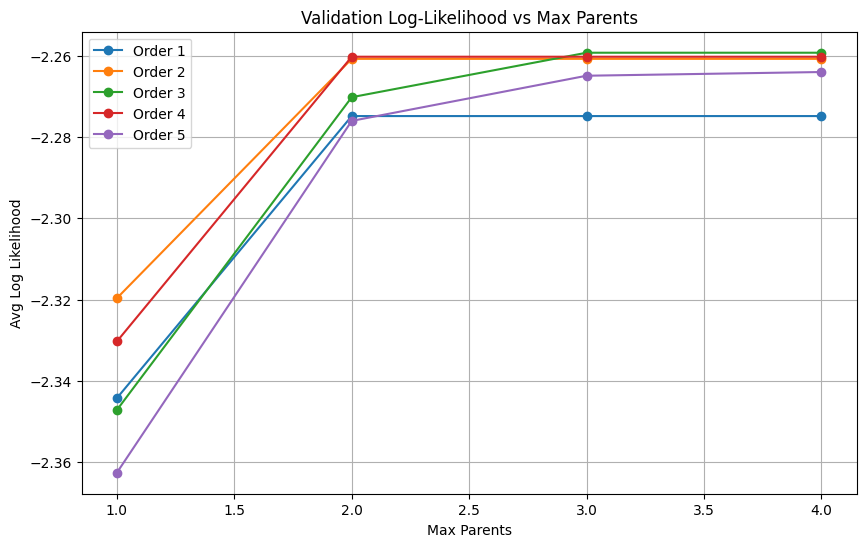

In [13]:
nodes = df.columns.to_list()
orders = [np.random.permutation(nodes).tolist() for _ in range(5)]
max_parent_list = [1, 2, 3, 4]

results_a = {'order_idx': [], 'max_parents': [], 'score': [], 'edges': []}
best_edges = []
best_score_global = -np.inf

for i, order in enumerate(orders):
    for mp in max_parent_list:
        current_edges = []

        for node_idx, node in enumerate(order):
            parents = []
            predecessors = order[:node_idx]

            best_local_score = calculate_k2_node(node, [], train_data)

            while len(parents) < mp and predecessors:
                temp_best_score = -np.inf
                temp_best_parent = None

                for pred in predecessors:
                    if pred not in parents:
                        current_parents = parents + [pred]
                        score  = calculate_k2_node(node, current_parents, train_data)

                        if score > temp_best_score:
                            temp_best_score = score
                            temp_best_parent = pred

                if temp_best_score > best_local_score:
                    best_local_score = temp_best_score
                    parents.append(temp_best_parent)
                    current_edges.append((temp_best_parent, node))
                else: 
                    break


        val_score = get_average_log_likelihood(current_edges, val_data)

        results_a['order_idx'].append(i)
        results_a['max_parents'].append(mp)
        results_a['score'].append(val_score)
        results_a['edges'].append(current_edges)

        if val_score > best_score_global:
                best_score_global = val_score
                best_edges = current_edges


plt.figure(figsize=(10, 6))
df_results = pd.DataFrame(results_a)

for i in range(len(orders)):
    subset = df_results[df_results['order_idx'] == i]
    plt.plot(subset['max_parents'], subset['score'], marker='o', label=f'Order {i+1}')

plt.title('Validation Log-Likelihood vs Max Parents')
plt.xlabel('Max Parents')
plt.ylabel('Avg Log Likelihood')
plt.legend()
plt.grid(True)
plt.show()


Classification

In [14]:
def calculate_f1(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true==1) & (y_pred==1))
    FP = np.sum((y_true==0) & (y_pred==1))
    TN = np.sum((y_true==0) & (y_pred==0))
    FN = np.sum((y_true==1) & (y_pred==0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-10)
    recall = TP / (TP + FN + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

    return accuracy, precision, recall, f1


In [15]:
true_edges = [('A', 'T'), ('S', 'L'), ('S', 'B'), ('T', 'E'), ('L', 'E'), ('E', 'X'), ('E', 'D'), ('B', 'D')]

In [16]:
print(best_edges)

[('T', 'A'), ('L', 'B'), ('B', 'S'), ('L', 'S'), ('B', 'D'), ('L', 'D'), ('T', 'D'), ('L', 'E'), ('T', 'E'), ('E', 'X')]


Best K2              | 0.9990   | 1.0000   | 0.9848   | 0.9924
Naive Bayes          | 0.9920   | 0.8919   | 1.0000   | 0.9429
True Structure       | 0.9990   | 1.0000   | 0.9848   | 0.9924


(array([0, 1, 2]),
 [Text(0, 0, 'Best K2'),
  Text(1, 0, 'Naive Bayes'),
  Text(2, 0, 'True Structure')])

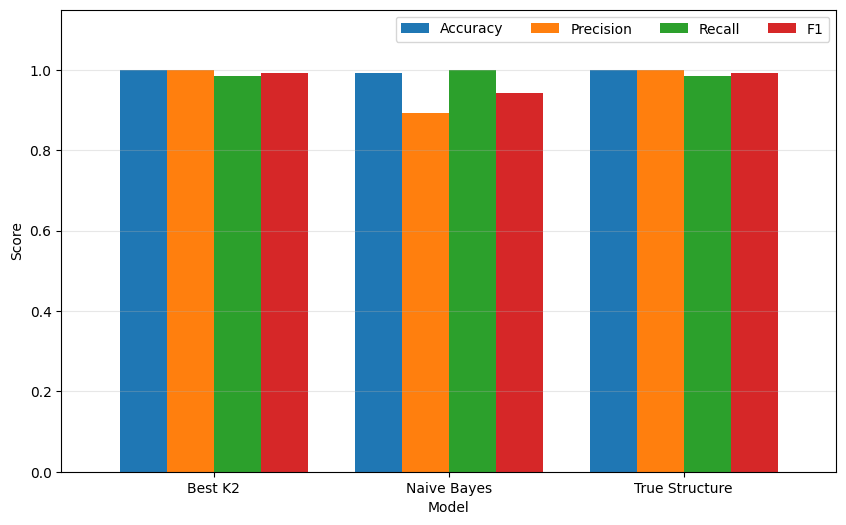

In [ ]:
naive_edges = [( 'L', col) for col in nodes if col != 'L']

full_train_data = pd.concat([train_data, val_data], ignore_index=True)

models = {
    "Best K2": best_edges,
    "Naive Bayes": naive_edges,
    "True Structure": true_edges
}

results_metrics = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}

for name, edges in models.items():
    bn = BayesianNetwork(edges, nodes)
    bn.fit(full_train_data)
    
    y_true = test_data['L'].values
    y_pred = bn.predict(test_data, target='L')
    
    accuracy, precision, recall, f1 = calculate_f1(y_true, y_pred)
    
    results_metrics['Model'].append(name)
    results_metrics['Accuracy'].append(accuracy)
    results_metrics['Precision'].append(precision)
    results_metrics['Recall'].append(recall)
    results_metrics['F1'].append(f1)
    
    print(f"{name:<20} | {accuracy:.4f}   | {precision:.4f}   | {recall:.4f}   | {f1:.4f}")



df_metrics = pd.DataFrame(results_metrics)
df_metrics.set_index('Model', inplace=True)

ax = df_metrics.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right', ncol=4)
plt.xticks(rotation=0)